# **Aprendizado de Máquina** <BR>**Aula 04** - Regressão logística binária e problemas de classificação

# **Exercício 2**: Análise de Crédito

## **1)** Importação de bibliotecas e classes

In [1]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [28]:
# Bibliotecas específicas de Machine Learning
from sklearn.linear_model import LogisticRegression   # NOVIDADE!
from sklearn.model_selection import train_test_split

## **2)** Leitura de dados e exploração inicial

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [9]:
# ATENÇÃO: "monte" o disco e ajuste o caminho do arquivo de dados
# antes da executar esta célula!

# Leitura dos dados de TREINO e exibição do DataFrame
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/A04EX2-credito.csv")
display(df)

,Status,Renda,Dependentes,Vinculo
0,0,2.5,3,1
1,1,1.7,3,1
2,0,4.0,2,1
3,1,2.3,2,1
4,1,3.7,4,0
...,...,...,...,...
87,1,1.3,2,1
88,1,2.4,2,1
89,0,4.3,2,0
90,1,1.8,0,1


### **2.1)** Caracaterísticas gerais

In [53]:
# Contagem de classes da resposta/target
print("0 = Adimplente; 1 = Inadimplente:\n")  # "\n" gera um salto de linha
print(df['Status'].value_counts())

0 = Adimplente; 1 = Inadimplente:

Status
0    51
1    41
Name: count, dtype: int64


### **2.2)** Gráfico

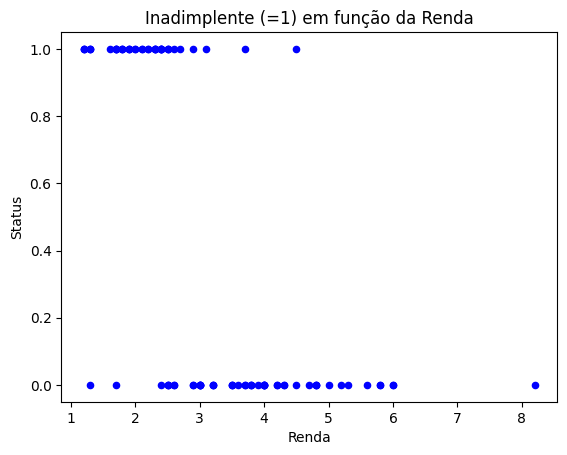

In [54]:
# Diagrama de dispersão entre a ocorrência de falha (y) e a temperatura
df.plot.scatter(x = 'Renda',y = 'Status',color = 'blue')
plt.title("Inadimplente (=1) em função da Renda")
plt.xlabel("Renda")
plt.ylabel("Status")
plt.show()

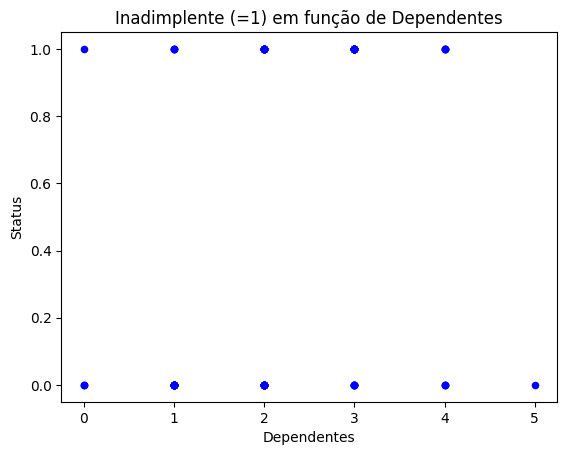

In [55]:
# Diagrama de dispersão entre a ocorrência de falha (y) e a temperatura
df.plot.scatter(x = 'Dependentes',y = 'Status',color = 'blue')
plt.title("Inadimplente (=1) em função de Dependentes")
plt.xlabel("Dependentes")
plt.ylabel("Status")
plt.show()

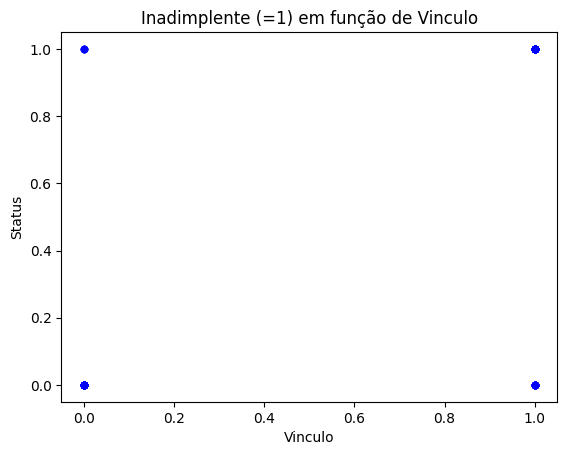

In [56]:
# Diagrama de dispersão entre a ocorrência de falha (y) e a temperatura
df.plot.scatter(x = 'Vinculo',y = 'Status',color = 'blue')
plt.title("Inadimplente (=1) em função de Vinculo")
plt.xlabel("Vinculo")
plt.ylabel("Status")
plt.show()

## **3)** Seleção de variáveis

In [23]:
y = df['Status']  # Variável dependente
X = df.drop(columns = 'Status')  # Variáveis independentes

In [30]:
# OBS.: se fosse necessário separar os dados disponíveis (X,y) em conjuntos de treino e teste:
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8,random_state = 42)

# Parâmetros da função 'train_test_split':
#X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# train_size/test_size = percentual de dados de treino/teste. Padrão: 75% (treino) e 25% (teste)
# random_state = controle (valor inteiro) da aleatoriedade da divisão
print("Dimensões dos dados de treino:",X_treino.shape)
print("Dimensões dos dados de teste:",X_teste.shape)

Dimensões dos dados de treino: (73, 3)
Dimensões dos dados de teste: (19, 3)


## **4)** Treinamento do <u>classificador</u> (modelo de regressão logística binária)

In [31]:
clf_RL = LogisticRegression()   # Cria instância de um classificador por reg. log. binária
clf_RL.fit(X_treino,y_treino)   # Treina o classificador

# Exibição dos coeficientes do modelo
print("Beta0 =",clf_RL.intercept_)
print("Beta1 =",clf_RL.coef_)

Beta0 = [2.62477513]
Beta1 = [[-1.82299204  0.69491234  1.90983368]]


## **5)** Previsões pontuais (*Renda* = 1,7 e *Renda* = 4,5)

In [60]:
# Criação de um DICIONÁRIO com os dados de previsão
X_prev_dict = {'Renda': [1.7, 4.5], 'Dependentes': [0, 1],'Vinculo': [0, 1]}

# Conversão do dicionário em um DataFrame
X_prev_df = pd.DataFrame(data = X_prev_dict)
X_prev_df

,Renda,Dependentes,Vinculo
0,1.7,0,0
1,4.5,1,1


In [47]:
# Cálculo das PROBABILIDADES previstas: método "predict_proba"
# Exibe P(Falha|Temp = 58) e P(Falha|Temp = 75)
# Serão mostradas duas colunas, com P(y=0) e P(y=1)

print("Probabilidades previstas:")
print(clf_RL.predict_proba(X_prev_df))

Probabilidades previstas:
[[0.44507232 0.55492768]
 [0.97512871 0.02487129]]


In [48]:
# CLASSIFICAÇÕES previstas: método "predict"

print("Classificações previstas:")
print(clf_RL.predict(X_prev_df))

Classificações previstas:
[1 0]


## **7)** Avaliação <u>preliminar</u> da qualidade do classificador (usando os dados de treino)

In [36]:
# Avaliação PRELIMINAR, via acurácia de ressubstituição
from sklearn.metrics import accuracy_score

# Calcula as previsões do classificador para os dados de treino (ressubstituição)
y_prev_treino = clf_RL.predict(X_treino)

# Acurácia
print("'Acurácia preliminar' =",accuracy_score(y_true = y_treino,y_pred = y_prev_treino))

'Acurácia preliminar' = 0.9452054794520548


## **8)** Avaliação da qualidade do classificador: validação cruzada *hold-out*

In [39]:
# Cálculo da acurácia
from sklearn.metrics import accuracy_score


y_prev_teste = clf_RL.predict(X_teste)  # Previsões para os dados de teste
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_prev_teste))

Acurácia = 0.6842105263157895


In [40]:
# Exibição "básica" da matriz de confusão
from sklearn.metrics import confusion_matrix

confusion_matrix(y_true = y_teste,y_pred = y_prev_teste)

array([[7, 5],
       [1, 6]])

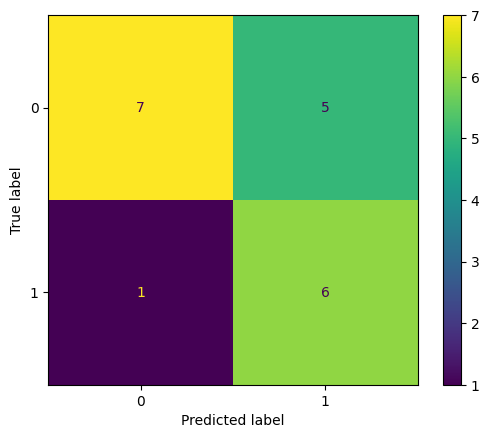

In [41]:
# Representação "gráfica" da matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_prev_teste)
plt.show()

In [42]:
# Relatório das métricas de qualidade
from sklearn.metrics import classification_report

print(classification_report(y_true = y_teste,y_pred = y_prev_teste,digits = 4))

              precision    recall  f1-score   support

           0     0.8750    0.5833    0.7000        12
           1     0.5455    0.8571    0.6667         7

    accuracy                         0.6842        19
   macro avg     0.7102    0.7202    0.6833        19
weighted avg     0.7536    0.6842    0.6877        19



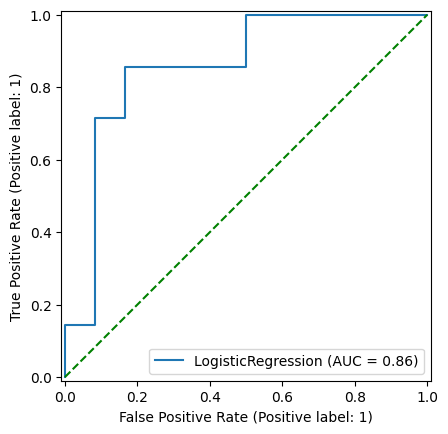

In [43]:
# Exibição da curva ROC
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(estimator = clf_RL,X = X_teste,y = y_teste)

# Acrescenta ao gráfico a curva ROC de um modelo puramente aleatório
plt.plot([0,1],[0,1],'g--')   # Linha verde (color = 'green') tracejada
plt.show()

---
**Fim do Exemplo 1 da Aula 04**